<a href="https://colab.research.google.com/github/VasilisPapageorgiou/Cameroon/blob/main/RealCameroonExpSupplementary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

================ SOURCE INFORMATION ================

reporting                   trace=78.879366
recovery_followup           trace=10.000000
transmission_investigation  trace=10.000000

================ FITTED DOMINANCE ===================

Non-dominated: ['Recovery']
Clearly separated: ['Weak', 'VeryWeak', 'Minimal']
Near boundary: ['Contact', 'BalancedA', 'BalancedB']

Number of DT functionals = 30
nu range = 0.0004 0.03125894155198703
Evaluating budget B=0.5000
Evaluating budget B=0.6341
Evaluating budget B=0.8042
Evaluating budget B=1.0200
Evaluating budget B=1.2936
Evaluating budget B=1.6407
Evaluating budget B=2.0808
Evaluating budget B=2.6390
Evaluating budget B=3.3470
Evaluating budget B=4.0000
Evaluating budget B=4.2449
Evaluating budget B=5.3836
Evaluating budget B=6.8278
Evaluating budget B=8.6595
Evaluating budget B=10.9826
Evaluating budget B=1

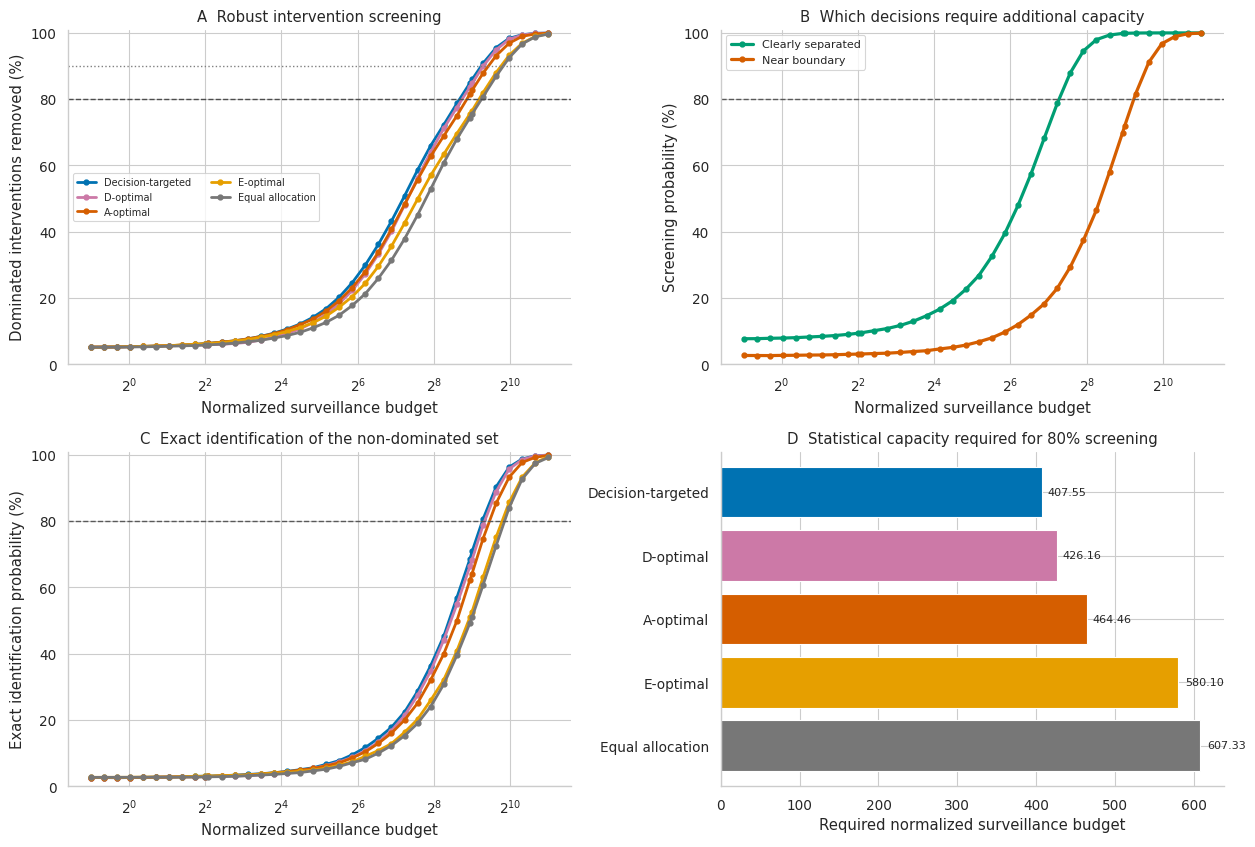

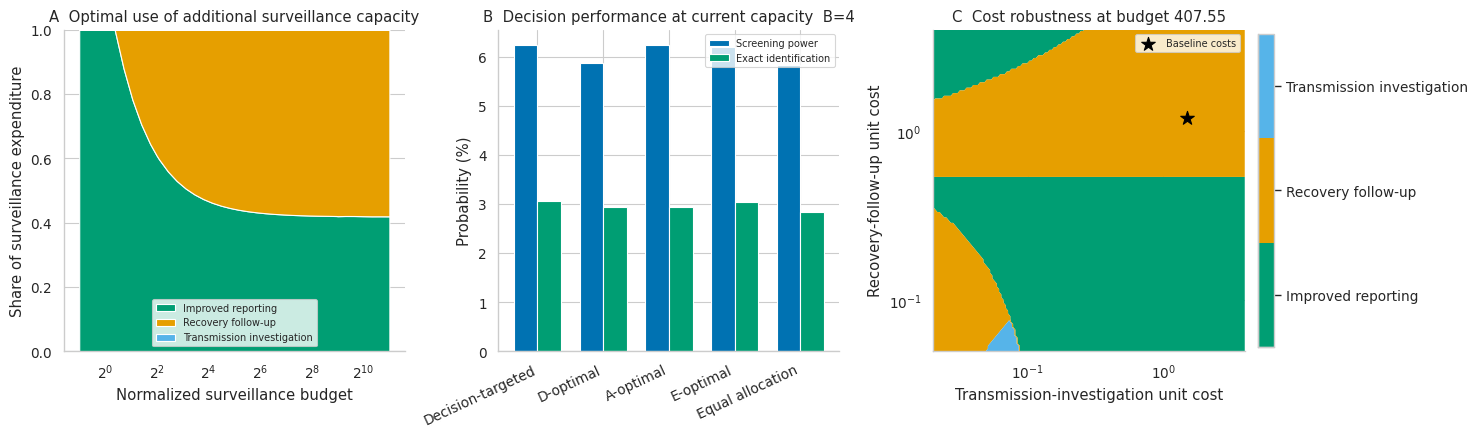


================ UPDATED TABLE 1 ====================

           Method    B80    B90  B80_sep  B80_near  B80_exact
Decision-targeted 407.55 602.21   154.78    601.39     616.60
        D-optimal 426.16 625.68   170.88    624.50     641.56
        A-optimal 464.46 686.30   164.39    685.96     701.91
        E-optimal 580.10 861.88   195.22    861.37     877.97
 Equal allocation 607.33 902.29   234.86    901.34     923.68

================ CURRENT CAPACITY B=4 ===============

           Method  FalseElimination  ScreeningPower  SeparatedPower  NearPower  ExactIdentification  DecisionU
Decision-targeted           0.00000         0.06244         0.09383    0.03106              0.03067    0.90180
        D-optimal           0.00017         0.05883         0.08783    0.02983              0.02933    0.93226
        A-optimal           0.00000         0.06244         0.09472    0.03017              0.02950    0.91352
        E-optimal           0.00000         0.06208         0.09317    0

In [8]:
# ======================================================================
# CAMEROON MPOX — DECISION-TARGETED SURVEILLANCE ALLOCATION
# FINAL MANUSCRIPT IMPLEMENTATION
#
# DT allocation:
#     w_DT(B) = argmin U(w)
#
# U(w) uses 30 recovery-reference decision functionals.
# Full pairwise robust screening is used only for external evaluation.
#
# Figure 3C:
#     c_tr  in [0.02, 4.0]
#     c_rec in [0.05, 4.0]
#     grid = 120 x 140
#     smooth discrete regions via contourf
# ======================================================================

import os, sys, json, warnings, subprocess
from functools import lru_cache
warnings.filterwarnings("ignore")

# ======================================================================
# PACKAGES
# ======================================================================

try:
    import cvxpy as cp
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "cvxpy"]
    )
    import cvxpy as cp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import solve_ivp
from scipy.stats import chi2

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.12
)

# ======================================================================
# OUTPUT DIRECTORY
# ======================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/MyDrive/Cameroon_Final_Decision_Targeted"
except Exception:
    ROOT = "./Cameroon_Final_Decision_Targeted"

OUT = f"{ROOT}/results"
os.makedirs(OUT, exist_ok=True)

# ======================================================================
# 1. FIXED CAMEROON CALIBRATION
# ======================================================================

N = 175.0
S0 = 114.0
I0 = 1.0
R0 = 60.0

BETA = 0.7650
GAMMA = 0.2377
PHI = 2.4906

ETA = np.log([
    BETA,
    GAMMA
])

SIGMA0 = np.array([
    [0.010786, 0.010329],
    [0.010329, 0.016702]
])

IBASE = np.linalg.inv(
    SIGMA0
)

T = 24

THRESH = np.array([
    57,
    68,
    80,
    91,
    103
])

# ======================================================================
# 2. INTERVENTIONS
# ======================================================================

POL = {
    "Recovery":  (0.000, 0.040),
    "Contact":   (0.100, 0.000),
    "BalancedA": (0.050, 0.020),
    "BalancedB": (0.070, 0.012),
    "Weak":      (0.045, 0.005),
    "VeryWeak":  (0.025, 0.004),
    "Minimal":   (0.010, 0.002)
}

A = list(POL)
K = len(A)

REF = "Recovery"

ALT = [
    a for a in A
    if a != REF
]

NEAR = {
    "Contact",
    "BalancedA",
    "BalancedB"
}

SEPARATED = {
    "Weak",
    "VeryWeak",
    "Minimal"
}

# ======================================================================
# 3. SURVEILLANCE INFORMATION MATRICES
# ======================================================================

REPORTING_FRACTION = 0.25
RECOVERY_OBS = 10.0
TRANSMISSION_OBS = 10.0

COST = {
    "reporting": 1.0,
    "recovery_followup": 1.2,
    "transmission_investigation": 1.5
}

def mu_week(eta, H=T):

    b, g = np.exp(
        eta
    )

    def rhs(t, z):

        S, I, R = z

        q = (
            b*S*I/N
        )

        return [
            -q,
            q-g*I,
            g*I
        ]

    sol = solve_ivp(
        rhs,
        [0, H],
        [S0, I0, R0],
        t_eval=np.arange(H+1),
        rtol=1e-9,
        atol=1e-11
    )

    return np.maximum(
        sol.y[0, :-1]
        -
        sol.y[0, 1:],
        1e-12
    )


def jacobian_mu(
    eta,
    eps=2e-5
):

    eye = np.eye(
        len(eta)
    )

    return np.column_stack([
        (
            mu_week(
                eta + eps*eye[j]
            )
            -
            mu_week(
                eta - eps*eye[j]
            )
        )/(2*eps)

        for j in range(
            len(eta)
        )
    ])


def reporting_information():

    mu = mu_week(
        ETA
    )

    J = jacobian_mu(
        ETA
    )

    var = (
        mu
        +
        mu**2/PHI
    )

    return (
        J.T
        @
        (
            J
            /
            var[:, None]
        )
    )


IREP = (
    REPORTING_FRACTION
    *
    reporting_information()
)

IREC = np.array([
    [0.0, 0.0],
    [0.0, RECOVERY_OBS]
])

ITRA = np.array([
    [TRANSMISSION_OBS, 0.0],
    [0.0, 0.0]
])

IJ = {
    "reporting":
        IREP,

    "recovery_followup":
        IREC,

    "transmission_investigation":
        ITRA
}

SRC = list(
    IJ
)

C = np.array([
    COST[s]
    for s in SRC
])

print(
    "\n================ SOURCE INFORMATION ================\n"
)

for s in SRC:

    print(
        f"{s:27s} "
        f"trace={np.trace(IJ[s]):.6f}"
    )

# ======================================================================
# 4. EXACT FINAL-SIZE DISTRIBUTION
# ======================================================================

@lru_cache(
    maxsize=1000
)
def final_pmf_cached(
    b_key,
    g_key
):

    b = float(
        b_key
    )

    g = float(
        g_key
    )

    S = int(
        S0
    )

    I = int(
        I0
    )

    NN = int(
        N
    )

    X = {}

    for s in range(
        S+1
    ):

        for i in range(
            NN-s+1
        ):

            if (
                i == 0
                or
                s == 0
            ):

                z = np.zeros(
                    s+1
                )

                z[0] = 1.0

                X[
                    s,
                    i
                ] = z

                continue

            p_inf = (
                b*s/NN
            ) / (
                b*s/NN
                +
                g
            )

            rec = np.pad(
                X[
                    s,
                    i-1
                ],
                (
                    0,
                    s+1-len(
                        X[
                            s,
                            i-1
                        ]
                    )
                )
            )

            nxt = X[
                s-1,
                i+1
            ]

            inf = np.zeros(
                s+1
            )

            inf[
                1:1+len(nxt)
            ] = nxt

            X[
                s,
                i
            ] = (
                (1-p_inf)*rec
                +
                p_inf*inf
            )

    return X[
        S,
        I
    ]


def final_pmf(
    b,
    g
):

    return final_pmf_cached(
        round(
            float(b),
            12
        ),
        round(
            float(g),
            12
        )
    )


def risk(
    eta,
    intervention
):

    b, g = np.exp(
        eta
    )

    db, dg = POL[
        intervention
    ]

    pmf = final_pmf(
        max(
            b-db,
            1e-10
        ),
        g+dg
    )

    return np.array([
        (
            pmf[c+1:].sum()
            if c < len(pmf)-1
            else 0.0
        )
        for c in THRESH
    ])


CURVES = np.array([
    risk(
        ETA,
        a
    )
    for a in A
])

# ======================================================================
# 5. DOMINANCE STRUCTURE
# ======================================================================

DOM = np.zeros(
    (
        K,
        K
    ),
    dtype=bool
)

for l in range(
    K
):

    for k in range(
        K
    ):

        if l == k:
            continue

        DOM[
            l,
            k
        ] = (
            np.all(
                CURVES[l]
                <=
                CURVES[k]
                +
                1e-12
            )
            and
            np.any(
                CURVES[l]
                <
                CURVES[k]
                -
                1e-12
            )
        )


oracle_dom = np.array([
    DOM[
        :,
        k
    ].any()

    for k in range(
        K
    )
])


oracle_nd = np.where(
    ~oracle_dom
)[0]


SEP_IDX = np.array([
    i

    for i, a in enumerate(
        A
    )

    if (
        a in SEPARATED
        and
        oracle_dom[i]
    )
])


NEAR_IDX = np.array([
    i

    for i, a in enumerate(
        A
    )

    if (
        a in NEAR
        and
        oracle_dom[i]
    )
])


print(
    "\n================ FITTED DOMINANCE ===================\n"
)

print(
    "Non-dominated:",
    [
        A[i]
        for i in oracle_nd
    ]
)

print(
    "Clearly separated:",
    [
        A[i]
        for i in SEP_IDX
    ]
)

print(
    "Near boundary:",
    [
        A[i]
        for i in NEAR_IDX
    ]
)

# ======================================================================
# 6. NUMERICAL JACOBIAN
# ======================================================================

def jac(
    fun,
    x,
    eps=1e-4
):

    eye = np.eye(
        len(x)
    )

    return np.column_stack([
        (
            fun(
                x
                +
                eps*eye[j]
            )
            -
            fun(
                x
                -
                eps*eye[j]
            )
        )/(2*eps)

        for j in range(
            len(x)
        )
    ])

# ======================================================================
# 7. 30 REFERENCE-BASED DECISION FUNCTIONALS
# ======================================================================

def reference_contrast_vector(
    eta
):

    r_ref = risk(
        eta,
        REF
    )

    return np.concatenate([
        risk(
            eta,
            a
        )
        -
        r_ref

        for a in ALT
    ])


DEL_DT = reference_contrast_vector(
    ETA
)

G_DT = jac(
    reference_contrast_vector,
    ETA
)

NU_DT = np.maximum(
    np.abs(
        DEL_DT
    ),
    0.02
)**2


print(
    "\nNumber of DT functionals =",
    len(
        DEL_DT
    )
)

print(
    "nu range =",
    NU_DT.min(),
    NU_DT.max()
)

# ======================================================================
# 8. FULL PAIRWISE CONTRASTS FOR EVALUATION
# ======================================================================

def full_contrast_vector(
    eta
):

    R = [
        risk(
            eta,
            a
        )
        for a in A
    ]

    return np.concatenate([
        R[l]
        -
        R[k]

        for l in range(
            K
        )

        for k in range(
            K
        )

        if l != k
    ])


DEL_FULL = full_contrast_vector(
    ETA
)

G_FULL = jac(
    full_contrast_vector,
    ETA
)


PAIR_INDEX = []

q = 0

for l in range(
    K
):

    for k in range(
        K
    ):

        if l == k:
            continue

        idx = np.arange(
            q,
            q+len(
                THRESH
            )
        )

        PAIR_INDEX.append(
            (
                l,
                k,
                idx
            )
        )

        q += len(
            THRESH
        )

# ======================================================================
# 9. COVARIANCE
# ======================================================================

def Cov(
    w,
    IJ_=IJ
):

    info = IBASE.copy()

    for j, s in enumerate(
        SRC
    ):

        info += (
            w[j]
            *
            IJ_[s]
        )

    return np.linalg.inv(
        info
        +
        1e-12*np.eye(2)
    )

# ======================================================================
# 10. DECISION CRITERION U(w)
# ======================================================================

def decision_U(
    w,
    IJ_=IJ
):

    S = Cov(
        w,
        IJ_
    )

    var = np.einsum(
        "ij,jk,ik->i",
        G_DT,
        S,
        G_DT
    )

    return float(
        np.max(
            var
            /
            NU_DT
        )
    )

# ======================================================================
# 11. CVXPY SOLVER
# ======================================================================

def solve_cvxpy_problem(
    problem
):

    installed = cp.installed_solvers()

    if "CLARABEL" in installed:

        try:

            problem.solve(
                solver=
                    "CLARABEL",
                verbose=
                    False
            )

            if problem.status in (
                cp.OPTIMAL,
                cp.OPTIMAL_INACCURATE
            ):
                return

        except Exception:
            pass

    if "SCS" in installed:

        problem.solve(
            solver=
                "SCS",
            eps=
                1e-6,
            max_iters=
                100000,
            verbose=
                False
        )

        if problem.status in (
            cp.OPTIMAL,
            cp.OPTIMAL_INACCURATE
        ):
            return

    raise RuntimeError(
        f"CVXPY optimization failed: "
        f"{problem.status}"
    )


def information_expression(
    x,
    B,
    c,
    IJ_
):

    info = cp.Constant(
        IBASE
    )

    for j, s in enumerate(
        SRC
    ):

        info += (
            B*x[j]/c[j]
        ) * cp.Constant(
            IJ_[s]
        )

    return info

# ======================================================================
# 12. DECISION-TARGETED OPTIMIZATION
# ======================================================================

DT_CACHE = {}

def decision_targeted(
    B,
    c=C,
    IJ_=IJ,
    cache=True
):

    B = float(
        B
    )

    c = np.asarray(
        c,
        dtype=float
    )

    key = (
        round(
            B,
            8
        ),
        tuple(
            np.round(
                c,
                8
            )
        )
    )

    if (
        cache
        and
        IJ_ is IJ
        and
        key in DT_CACHE
    ):

        return DT_CACHE[
            key
        ].copy()

    x = cp.Variable(
        len(c),
        nonneg=True
    )

    INFO = information_expression(
        x,
        B,
        c,
        IJ_
    )

    terms = [
        cp.matrix_frac(
            cp.Constant(
                G_DT[r]
            ),
            INFO
        )
        /
        NU_DT[r]

        for r in range(
            len(
                G_DT
            )
        )
    ]

    problem = cp.Problem(
        cp.Minimize(
            cp.max(
                cp.hstack(
                    terms
                )
            )
        ),
        [
            cp.sum(x)
            <=
            1
        ]
    )

    solve_cvxpy_problem(
        problem
    )

    xx = np.maximum(
        np.asarray(
            x.value
        ).ravel(),
        0.0
    )

    if xx.sum() > 1:

        xx /= xx.sum()

    w = (
        B
        *
        xx
        /
        c
    )

    if (
        cache
        and
        IJ_ is IJ
    ):

        DT_CACHE[
            key
        ] = w.copy()

    return w

# ======================================================================
# 13. CONVENTIONAL OPTIMAL DESIGNS
# ======================================================================

CONV_CACHE = {}

def conventional(
    B,
    criterion,
    c=C,
    IJ_=IJ
):

    B = float(
        B
    )

    c = np.asarray(
        c,
        dtype=float
    )

    key = (
        criterion,
        round(
            B,
            8
        ),
        tuple(
            np.round(
                c,
                8
            )
        )
    )

    if (
        IJ_ is IJ
        and
        key in CONV_CACHE
    ):

        return CONV_CACHE[
            key
        ].copy()

    x = cp.Variable(
        len(c),
        nonneg=True
    )

    INFO = information_expression(
        x,
        B,
        c,
        IJ_
    )

    if criterion == "A":

        objective = cp.Minimize(
            sum(
                cp.matrix_frac(
                    cp.Constant(e),
                    INFO
                )
                for e in np.eye(2)
            )
        )

    elif criterion == "D":

        objective = cp.Maximize(
            cp.log_det(
                INFO
            )
        )

    elif criterion == "E":

        objective = cp.Maximize(
            cp.lambda_min(
                INFO
            )
        )

    else:

        raise ValueError(
            "criterion must be A, D, or E"
        )

    problem = cp.Problem(
        objective,
        [
            cp.sum(x)
            <=
            1
        ]
    )

    solve_cvxpy_problem(
        problem
    )

    xx = np.maximum(
        np.asarray(
            x.value
        ).ravel(),
        0.0
    )

    if xx.sum() > 1:

        xx /= xx.sum()

    w = (
        B
        *
        xx
        /
        c
    )

    if IJ_ is IJ:

        CONV_CACHE[
            key
        ] = w.copy()

    return w

# ======================================================================
# 14. EQUAL-EXPENDITURE BASELINE
# ======================================================================

def equal_budget(
    B,
    c=C
):

    return (
        float(B)
        /
        (
            len(c)
            *
            np.asarray(c)
        )
    )

# ======================================================================
# 15. ROBUST SCREENING EVALUATION
# ======================================================================

ALPHA = 0.05

RADIUS = np.sqrt(
    chi2.ppf(
        1-ALPHA,
        df=2
    )
)

NEVAL = 6000

rng = np.random.default_rng(
    4109
)

ZEVAL = rng.standard_normal(
    (
        NEVAL,
        2
    )
)


def screening_metrics(
    w,
    Z=ZEVAL,
    IJ_=IJ
):

    S = Cov(
        w,
        IJ_
    )

    L = np.linalg.cholesky(
        S
        +
        1e-14*np.eye(2)
    )

    E = (
        Z
        @
        L.T
    )

    var = np.einsum(
        "ij,jk,ik->i",
        G_FULL,
        S,
        G_FULL
    )

    sd = np.sqrt(
        np.maximum(
            var,
            1e-15
        )
    )

    DH = (
        DEL_FULL[
            None,
            :
        ]
        +
        E
        @
        G_FULL.T
    )

    UB = (
        DH
        +
        RADIUS
        *
        sd[
            None,
            :
        ]
    )

    removed = np.zeros(
        (
            len(Z),
            K
        ),
        dtype=bool
    )

    for l, k, idx in PAIR_INDEX:

        removed[
            :,
            k
        ] |= np.all(
            UB[
                :,
                idx
            ]
            <=
            0,
            axis=1
        )

    false = np.mean(
        np.any(
            removed[
                :,
                oracle_nd
            ],
            axis=1
        )
    )

    power = np.mean(
        removed[
            :,
            oracle_dom
        ]
    )

    separated = (
        np.mean(
            removed[
                :,
                SEP_IDX
            ]
        )
        if len(
            SEP_IDX
        )
        else
        np.nan
    )

    near = (
        np.mean(
            removed[
                :,
                NEAR_IDX
            ]
        )
        if len(
            NEAR_IDX
        )
        else
        np.nan
    )

    retained = (
        ~removed
    )

    exact = np.mean([
        np.array_equal(
            np.where(
                retained[i]
            )[0],
            oracle_nd
        )
        for i in range(
            len(Z)
        )
    ])

    return {
        "false":
            float(false),

        "power":
            float(power),

        "separated":
            float(separated),

        "near":
            float(near),

        "exact":
            float(exact)
    }

# ======================================================================
# 16. METHODS
# ======================================================================

METHODS = [
    "Decision-targeted",
    "D-optimal",
    "A-optimal",
    "E-optimal",
    "Equal allocation"
]


def allocation(
    method,
    B
):

    if method == "Decision-targeted":

        return decision_targeted(
            B
        )

    if method == "D-optimal":

        return conventional(
            B,
            "D"
        )

    if method == "A-optimal":

        return conventional(
            B,
            "A"
        )

    if method == "E-optimal":

        return conventional(
            B,
            "E"
        )

    if method == "Equal allocation":

        return equal_budget(
            B
        )

    raise ValueError(
        method
    )

# ======================================================================
# 17. EVALUATION CACHE
# ======================================================================

CACHE = {}

def evaluate(
    method,
    B
):

    key = (
        method,
        round(
            float(B),
            8
        )
    )

    if key in CACHE:

        return CACHE[
            key
        ]

    w = allocation(
        method,
        float(B)
    )

    M = screening_metrics(
        w
    )

    out = {
        "Budget":
            float(B),

        "Method":
            method,

        "FalseElimination":
            M[
                "false"
            ],

        "ScreeningPower":
            M[
                "power"
            ],

        "SeparatedPower":
            M[
                "separated"
            ],

        "NearPower":
            M[
                "near"
            ],

        "ExactIdentification":
            M[
                "exact"
            ],

        "DecisionU":
            decision_U(
                w
            ),

        **{
            SRC[j]:
                w[j]

            for j in range(
                len(SRC)
            )
        }
    }

    CACHE[
        key
    ] = out

    return out

# ======================================================================
# 18. BUDGET CURVES
# ======================================================================

BUDGETS = np.unique(
    np.r_[
        np.geomspace(
            0.5,
            2048,
            36
        ),
        4.0,
        512.0
    ]
)

records = []

for B in BUDGETS:

    print(
        f"Evaluating budget "
        f"B={B:.4f}"
    )

    for method in METHODS:

        records.append(
            evaluate(
                method,
                B
            )
        )

BR = pd.DataFrame(
    records
)

BR.to_csv(
    f"{OUT}/budget_results_updated.csv",
    index=False
)

# ======================================================================
# 19. CAPACITY THRESHOLDS
# ======================================================================

METRIC_MAP = {

    "B80":
        (
            "ScreeningPower",
            0.80
        ),

    "B90":
        (
            "ScreeningPower",
            0.90
        ),

    "B80Separated":
        (
            "SeparatedPower",
            0.80
        ),

    "B80Near":
        (
            "NearPower",
            0.80
        ),

    "B80Exact":
        (
            "ExactIdentification",
            0.80
        )
}

SEARCH_GRID = np.geomspace(
    0.25,
    4096,
    65
)


def capacity_threshold(
    method,
    metric,
    target,
    tol=0.02
):

    prev_B = SEARCH_GRID[
        0
    ]

    if evaluate(
        method,
        prev_B
    )[metric] >= target:

        return prev_B

    bracket = None

    for B in SEARCH_GRID[
        1:
    ]:

        value = evaluate(
            method,
            B
        )[metric]

        if value >= target:

            bracket = (
                prev_B,
                B
            )

            break

        prev_B = B

    if bracket is None:

        return np.nan

    lo, hi = bracket

    for _ in range(
        45
    ):

        if (
            hi-lo
            <=
            tol
        ):
            break

        mid = (
            0.5
            *
            (
                lo+hi
            )
        )

        value = evaluate(
            method,
            mid
        )[metric]

        if value >= target:
            hi = mid
        else:
            lo = mid

    return hi

# ======================================================================
# 20. TABLE 1
# ======================================================================

table_rows = []

for method in METHODS:

    print(
        "\nCapacity thresholds:",
        method
    )

    vals = {}

    for key, (
        metric,
        target
    ) in METRIC_MAP.items():

        vals[
            key
        ] = capacity_threshold(
            method,
            metric,
            target
        )

        print(
            key,
            vals[
                key
            ]
        )

    table_rows.append({

        "Method":
            method,

        "B80":
            vals[
                "B80"
            ],

        "B90":
            vals[
                "B90"
            ],

        "B80_sep":
            vals[
                "B80Separated"
            ],

        "B80_near":
            vals[
                "B80Near"
            ],

        "B80_exact":
            vals[
                "B80Exact"
            ]
    })


TABLE1 = pd.DataFrame(
    table_rows
)

for col in TABLE1.columns[
    1:
]:

    TABLE1[
        col
    ] = TABLE1[
        col
    ].round(
        2
    )


TABLE1.to_csv(
    f"{OUT}/table1_updated.csv",
    index=False
)


with open(
    f"{OUT}/table1_updated.tex",
    "w"
) as f:

    f.write(
        TABLE1.to_latex(
            index=False,
            escape=False,
            float_format="%.2f"
        )
    )


print(
    "\n================ UPDATED TABLE 1 ================\n"
)

print(
    TABLE1.to_string(
        index=False
    )
)

# ======================================================================
# 21. CURRENT CAPACITY B=4
# ======================================================================

B0 = 4.0

MAIN = pd.DataFrame([
    evaluate(
        method,
        B0
    )
    for method in METHODS
])

# ======================================================================
# 22. DT ALLOCATION PATH
# ======================================================================

DT = (
    BR[
        BR.Method
        ==
        "Decision-targeted"
    ]
    .sort_values(
        "Budget"
    )
)

shares = []

for _, row in DT.iterrows():

    effort = np.array([
        row[s]
        for s in SRC
    ])

    expenditure = (
        effort
        *
        C
    )

    total = expenditure.sum()

    share = (
        expenditure/total
        if total > 0
        else np.zeros_like(
            expenditure
        )
    )

    share[
        np.abs(
            share
        )
        <
        1e-7
    ] = 0.0

    if share.sum() > 0:

        share /= share.sum()

    shares.append([
        row.Budget,
        *share
    ])


SH = pd.DataFrame(
    shares,
    columns=[
        "Budget",
        *SRC
    ]
)

# ======================================================================
# 23. HIGH-RESOLUTION COST ROBUSTNESS
#
# EXACT REQUEST:
#
# c_tr  in [0.02, 4.0]
# c_rec in [0.05, 4.0]
#
# 120 x 140 logarithmic grid
# ======================================================================

B_HEAT = float(
    TABLE1.loc[
        TABLE1.Method
        ==
        "Decision-targeted",
        "B80"
    ].iloc[
        0
    ]
)

# y-axis
C_REC = np.geomspace(
    0.05,
    4.0,
    120
)

# x-axis
C_TR = np.geomspace(
    0.02,
    4.0,
    140
)

WIN = np.zeros(
    (
        len(C_REC),
        len(C_TR)
    ),
    dtype=int
)

print(
    "\n================ HIGH-RESOLUTION COST ROBUSTNESS ================\n"
)

print(
    f"Grid size = "
    f"{len(C_REC)} x {len(C_TR)} "
    f"= {len(C_REC)*len(C_TR)} optimizations"
)

for i, c_rec in enumerate(
    C_REC
):

    print(
        f"Cost robustness row "
        f"{i+1:03d}/{len(C_REC):03d}"
    )

    for j, c_tr in enumerate(
        C_TR
    ):

        cc = np.array([
            1.0,
            c_rec,
            c_tr
        ])

        w = decision_targeted(
            B_HEAT,
            c=cc,
            IJ_=IJ,
            cache=True
        )

        expenditure = (
            w
            *
            cc
        )

        WIN[
            i,
            j
        ] = int(
            np.argmax(
                expenditure
            )
        )


print(
    "\nSources represented in Panel 3C:"
)

for j in np.unique(
    WIN
):

    print(
        " -",
        SRC[
            j
        ]
    )

# ======================================================================
# 24. COLORS
# ======================================================================

COL = {

    "Decision-targeted":
        "#0072B2",

    "A-optimal":
        "#D55E00",

    "D-optimal":
        "#CC79A7",

    "E-optimal":
        "#E69F00",

    "Equal allocation":
        "#777777"
}


SOURCE_COLORS = [
    "#009E73",
    "#E69F00",
    "#56B4E9"
]

# ======================================================================
# 25. FIGURE 2
# ======================================================================

fig, ax = plt.subplots(
    2,
    2,
    figsize=(
        12.7,
        8.6
    )
)

# ----------------------------------------------------------------------
# Panel A
# ----------------------------------------------------------------------

for method in METHODS:

    g = (
        BR[
            BR.Method
            ==
            method
        ]
        .sort_values(
            "Budget"
        )
    )

    ax[
        0,
        0
    ].plot(
        g.Budget,
        100*g.ScreeningPower,
        "o-",
        lw=2.0,
        ms=3.5,
        color=
            COL[
                method
            ],
        label=
            method
    )


ax[
    0,
    0
].axhline(
    80,
    color=".30",
    ls="--",
    lw=1
)

ax[
    0,
    0
].axhline(
    90,
    color=".50",
    ls=":",
    lw=1
)

ax[
    0,
    0
].set_xscale(
    "log",
    base=2
)

ax[
    0,
    0
].set(
    title=
        "A  Robust intervention screening",

    xlabel=
        "Normalized surveillance budget",

    ylabel=
        "Dominated interventions removed (%)",

    ylim=(
        0,
        101
    )
)

ax[
    0,
    0
].legend(
    fontsize=7,
    ncol=2
)

# ----------------------------------------------------------------------
# Panel B
# ----------------------------------------------------------------------

ax[
    0,
    1
].plot(
    DT.Budget,
    100*DT.SeparatedPower,
    "o-",
    lw=2.3,
    ms=3.5,
    label=
        "Clearly separated",
    color=
        "#009E73"
)

ax[
    0,
    1
].plot(
    DT.Budget,
    100*DT.NearPower,
    "o-",
    lw=2.3,
    ms=3.5,
    label=
        "Near boundary",
    color=
        "#D55E00"
)

ax[
    0,
    1
].axhline(
    80,
    color=".35",
    ls="--",
    lw=1
)

ax[
    0,
    1
].set_xscale(
    "log",
    base=2
)

ax[
    0,
    1
].set(
    title=
        "B  Which decisions require additional capacity",

    xlabel=
        "Normalized surveillance budget",

    ylabel=
        "Screening probability (%)",

    ylim=(
        0,
        101
    )
)

ax[
    0,
    1
].legend(
    fontsize=8
)

# ----------------------------------------------------------------------
# Panel C
# ----------------------------------------------------------------------

for method in METHODS:

    g = (
        BR[
            BR.Method
            ==
            method
        ]
        .sort_values(
            "Budget"
        )
    )

    ax[
        1,
        0
    ].plot(
        g.Budget,
        100*g.ExactIdentification,
        "o-",
        lw=2.0,
        ms=3.5,
        color=
            COL[
                method
            ]
    )


ax[
    1,
    0
].axhline(
    80,
    color=".35",
    ls="--",
    lw=1
)

ax[
    1,
    0
].set_xscale(
    "log",
    base=2
)

ax[
    1,
    0
].set(
    title=
        "C  Exact identification of the non-dominated set",

    xlabel=
        "Normalized surveillance budget",

    ylabel=
        "Exact identification probability (%)",

    ylim=(
        0,
        101
    )
)

# ----------------------------------------------------------------------
# Panel D
# ----------------------------------------------------------------------

cap80 = (
    TABLE1[
        [
            "Method",
            "B80"
        ]
    ]
    .dropna()
    .sort_values(
        "B80"
    )
)

ax[
    1,
    1
].barh(
    cap80.Method,
    cap80.B80,
    color=[
        COL[m]
        for m in cap80.Method
    ]
)

ax[
    1,
    1
].invert_yaxis()

ax[
    1,
    1
].set(
    title=
        "D  Statistical capacity required for 80% screening",

    xlabel=
        "Required normalized surveillance budget"
)

for i, value in enumerate(
    cap80.B80
):

    ax[
        1,
        1
    ].text(
        value*1.015,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )


sns.despine()
plt.tight_layout()

plt.savefig(
    f"{OUT}/decision_performance_updated.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/decision_performance_updated.pdf",
    bbox_inches="tight"
)

plt.show()

# ======================================================================
# 26. FIGURE 3
# ======================================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(
        14.9,
        4.5
    )
)

# ----------------------------------------------------------------------
# Panel A — baseline-cost allocation path
# ----------------------------------------------------------------------

ax[
    0
].stackplot(
    SH.Budget,
    SH[SRC].T.values,
    labels=[
        "Improved reporting",
        "Recovery follow-up",
        "Transmission investigation"
    ],
    colors=
        SOURCE_COLORS
)

ax[
    0
].set_xscale(
    "log",
    base=2
)

ax[
    0
].set(
    title=
        "A  Optimal use of additional surveillance capacity",

    xlabel=
        "Normalized surveillance budget",

    ylabel=
        "Share of surveillance expenditure",

    ylim=(
        0,
        1
    )
)

ax[
    0
].legend(
    fontsize=7
)

# ----------------------------------------------------------------------
# Panel B — current capacity
# ----------------------------------------------------------------------

x = np.arange(
    len(
        MAIN
    )
)

bw = 0.36

ax[
    1
].bar(
    x-bw/2,
    100*MAIN.ScreeningPower,
    bw,
    color=
        "#0072B2",
    label=
        "Screening power"
)

ax[
    1
].bar(
    x+bw/2,
    100*MAIN.ExactIdentification,
    bw,
    color=
        "#009E73",
    label=
        "Exact identification"
)

ax[
    1
].set_xticks(
    x
)

ax[
    1
].set_xticklabels(
    MAIN.Method,
    rotation=25,
    ha="right"
)

ax[
    1
].set(
    title=
        f"B  Decision performance at current capacity  B={B0:g}",

    ylabel=
        "Probability (%)"
)

ax[
    1
].legend(
    fontsize=7
)

# ----------------------------------------------------------------------
# Panel C — HIGH-RESOLUTION cost robustness
# ----------------------------------------------------------------------

X, Y = np.meshgrid(
    C_TR,
    C_REC
)

cmap = (
    plt.matplotlib.colors
    .ListedColormap(
        SOURCE_COLORS
    )
)

# contourf gives visually smoother regime boundaries
# while preserving the discrete 3-class allocation regions

pc = ax[
    2
].contourf(
    X,
    Y,
    WIN,
    levels=[
        -0.5,
        0.5,
        1.5,
        2.5
    ],
    cmap=
        cmap,
    antialiased=
        True
)

ax[
    2
].set_xscale(
    "log"
)

ax[
    2
].set_yscale(
    "log"
)

ax[
    2
].set_xlim(
    0.02,
    4.0
)

ax[
    2
].set_ylim(
    0.05,
    4.0
)

ax[
    2
].scatter(
    COST[
        "transmission_investigation"
    ],
    COST[
        "recovery_followup"
    ],
    marker=
        "*",
    s=
        105,
    c=
        "black",
    zorder=
        6,
    label=
        "Baseline costs"
)

ax[
    2
].set(
    title=
        f"C  Cost robustness at budget {B_HEAT:.2f}",

    xlabel=
        "Transmission-investigation unit cost",

    ylabel=
        "Recovery-follow-up unit cost"
)

cb = fig.colorbar(
    pc,
    ax=ax[
        2
    ],
    ticks=[
        0,
        1,
        2
    ],
    fraction=.046,
    pad=.04
)

cb.ax.set_yticklabels([
    "Improved reporting",
    "Recovery follow-up",
    "Transmission investigation"
])

ax[
    2
].legend(
    fontsize=7,
    loc="upper right"
)

sns.despine()

plt.tight_layout()

plt.savefig(
    f"{OUT}/allocation_capacity_updated.png",
    dpi=450,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUT}/allocation_capacity_updated.pdf",
    bbox_inches="tight"
)

plt.show()

# ======================================================================
# 27. REPORT
# ======================================================================

print(
    "\n================ UPDATED TABLE 1 ====================\n"
)

print(
    TABLE1.to_string(
        index=False
    )
)


print(
    "\n================ CURRENT CAPACITY B=4 ===============\n"
)

print(
    MAIN[
        [
            "Method",
            "FalseElimination",
            "ScreeningPower",
            "SeparatedPower",
            "NearPower",
            "ExactIdentification",
            "DecisionU"
        ]
    ]
    .round(
        5
    )
    .to_string(
        index=False
    )
)


print(
    "\n================ DT CAPACITY SAVINGS =================\n"
)

C80 = (
    TABLE1
    .set_index(
        "Method"
    )[
        "B80"
    ]
)

bd = C80[
    "Decision-targeted"
]

for method in METHODS[
    1:
]:

    bm = C80[
        method
    ]

    saving = (
        100
        *
        (
            bm-bd
        )
        /
        bm
        if np.isfinite(
            bm
        )
        else
        np.nan
    )

    print(
        f"{method:18s}: "
        f"B80={bm:.2f}, "
        f"saving={saving:.2f}%"
    )


print(
    "\n================ PANEL 3C ============================\n"
)

print(
    "Grid:"
)

print(
    f"  {len(C_REC)} x {len(C_TR)} "
    f"= {len(C_REC)*len(C_TR)} cells"
)

print(
    "\nRecovery-follow-up cost range:"
)

print(
    f"  [{C_REC.min():.2f}, {C_REC.max():.2f}]"
)

print(
    "\nTransmission-investigation cost range:"
)

print(
    f"  [{C_TR.min():.2f}, {C_TR.max():.2f}]"
)

print(
    "\nSources represented:"
)

for j in np.unique(
    WIN
):

    print(
        " -",
        SRC[
            j
        ]
    )

# ======================================================================
# 28. SAVE SUMMARY
# ======================================================================

summary = {

    "fixed_parameters": {

        "N_eff":
            N,

        "S0":
            S0,

        "I0":
            I0,

        "R0":
            R0,

        "beta":
            BETA,

        "gamma":
            GAMMA,

        "phi":
            PHI
    },

    "decision_targeted_definition": {

        "reference":
            REF,

        "number_functionals":
            int(
                len(
                    DEL_DT
                )
            ),

        "thresholds":
            THRESH.tolist(),

        "normalization_floor":
            0.02
    },

    "panel3C": {

        "grid_rows":
            len(
                C_REC
            ),

        "grid_columns":
            len(
                C_TR
            ),

        "transmission_cost_range":
            [
                float(
                    C_TR.min()
                ),
                float(
                    C_TR.max()
                )
            ],

        "recovery_cost_range":
            [
                float(
                    C_REC.min()
                ),
                float(
                    C_REC.max()
                )
            ],

        "represented_sources":
            [
                SRC[j]
                for j in np.unique(
                    WIN
                )
            ]
    },

    "oracle_non_dominated":
        [
            A[i]
            for i in oracle_nd
        ],

    "table1":
        TABLE1.to_dict(
            "records"
        )
}


with open(
    f"{OUT}/summary_updated.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


print(
    "\nDONE"
)

print(
    "Figure 2:",
    f"{OUT}/decision_performance_updated.png"
)

print(
    "Figure 3:",
    f"{OUT}/allocation_capacity_updated.png"
)

print(
    "Table 1:",
    f"{OUT}/table1_updated.csv"
)


Reference non-dominated strategy used for gaps: Recovery-focused response

Non-dominated set: ['Recovery-focused response']

Near-boundary dominated: ['Balanced response A', 'Balanced response B', 'Contact-focused response']

Clearly dominated: ['Weak balanced response', 'Very weak response', 'Minimal response']

Summary table


,strategy,classification,mean_risk,sup_gap_vs_ref,dominated_by
4,Weak balanced response,clearly dominated,0.2897,0.0970,"Recovery-focused response, Contact-focused response, Balanced response A, Balanced response B"
5,Very weak response,clearly dominated,0.3180,0.1358,"Recovery-focused response, Contact-focused response, Balanced response A, Balanced response B, Weak balanced response"
6,Minimal response,clearly dominated,0.3434,0.1768,"Recovery-focused response, Contact-focused response, Balanced response A, Balanced response B, Weak balanced response, Very weak response"
2,Balanced response A,near-boundary dominated,0.2306,0.0095,Recovery-focused response
3,Balanced response B,near-boundary dominated,0.2334,0.0136,"Recovery-focused response, Balanced response A"
1,Contact-focused response,near-boundary dominated,0.2378,0.0204,"Recovery-focused response, Balanced response A, Balanced response B"
0,Recovery-focused response,non-dominated,0.2245,0.0000,-


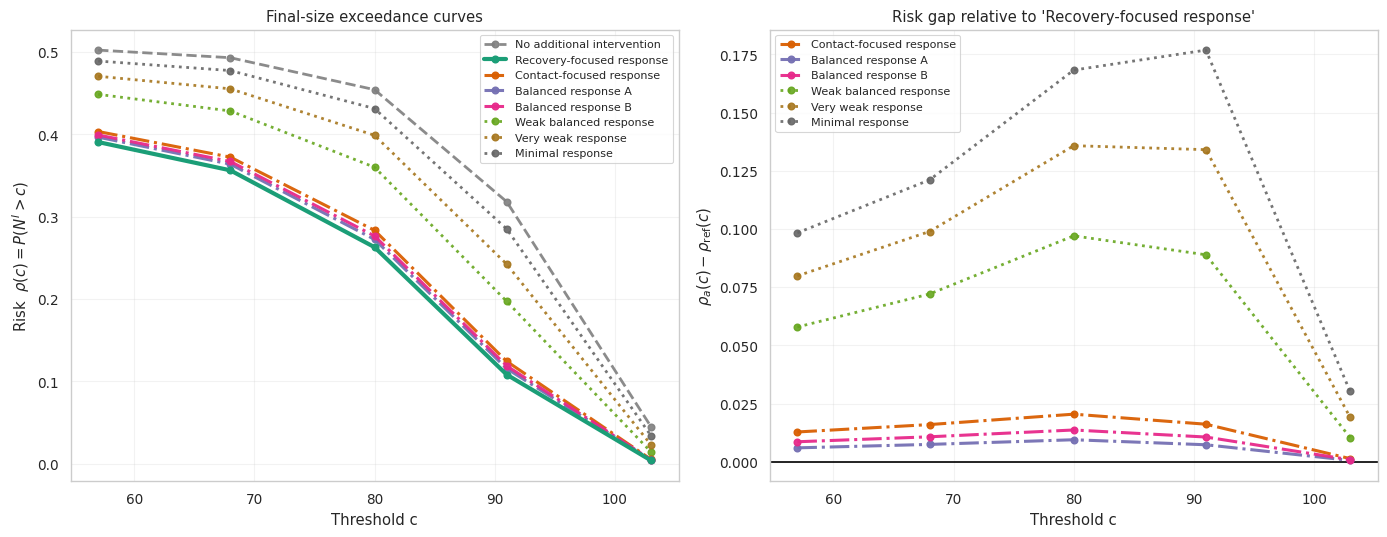


Pairwise dominance matrix: 1 means row dominates column


,Recovery-focused response,Contact-focused response,Balanced response A,Balanced response B,Weak balanced response,Very weak response,Minimal response
Recovery-focused response,0,1,1,1,1,1,1
Contact-focused response,0,0,0,0,1,1,1
Balanced response A,0,1,0,1,1,1,1
Balanced response B,0,1,0,0,1,1,1
Weak balanced response,0,0,0,0,0,1,1
Very weak response,0,0,0,0,0,0,1
Minimal response,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# Cameroon intervention-structure diagnostic figure
# Exact final-size risks + automatic dominance classification
# ============================================================



#############################################################
# I used only the 4th panel of this one!
#############################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache

# -----------------------------
# Fixed Cameroon calibration
# -----------------------------
N_eff   = 175
S0      = 114
I0      = 1
R0      = 60
b_hat   = 0.7650
g_hat   = 0.2377
phi_hat = 2.4906

thresholds = np.array([57, 68, 80, 91, 103], dtype=int)

# -----------------------------
# Strategies
# baseline kept only as reference, not in screening set
# -----------------------------
strategies = {
    "No additional intervention": (0.000, 0.000),
    "Recovery-focused response":  (0.000, 0.040),
    "Contact-focused response":   (0.100, 0.000),
    "Balanced response A":        (0.050, 0.020),
    "Balanced response B":        (0.070, 0.012),
    "Weak balanced response":     (0.045, 0.005),
    "Very weak response":         (0.025, 0.004),
    "Minimal response":           (0.010, 0.002),
}
screening_set = [k for k in strategies if k != "No additional intervention"]

# -----------------------------
# Exact final-size distribution
# N^I = number of new infections after time 0
# -----------------------------
def final_size_dist_exact(S, I, N, b, g):
    @lru_cache(None)
    def F(s, i):
        # returns probabilities P(N^I = n | current state=(s,i)), n=0,...,s
        if i == 0 or s == 0:
            out = np.zeros(s + 1)
            out[0] = 1.0
            return tuple(out)

        inf = b * s * i / N
        rec = g * i
        tot = inf + rec

        out = np.zeros(s + 1)

        # recovery next
        d_rec = np.array(F(s, i - 1))
        out += (rec / tot) * d_rec

        # infection next
        d_inf = np.array(F(s - 1, i + 1))  # length s
        out[1:] += (inf / tot) * d_inf

        return tuple(out)

    return np.array(F(S, I))

def exceedance_curve(S, I, N, b, g, cuts):
    pmf = final_size_dist_exact(S, I, N, b, g)
    cdf = np.cumsum(pmf)
    out = []
    for c in cuts:
        out.append(0.0 if c >= len(pmf) else 1.0 - cdf[c])
    return np.array(out), pmf

# -----------------------------
# Compute risk curves
# -----------------------------
risk_curves = {}
pmfs = {}

for name, (db, dg) in strategies.items():
    b = b_hat - db
    g = g_hat + dg
    curve, pmf = exceedance_curve(S0, I0, N_eff, b, g, thresholds)
    risk_curves[name] = curve
    pmfs[name] = pmf

risk_df = pd.DataFrame(risk_curves, index=thresholds).T
risk_df.index.name = "strategy"

# -----------------------------
# Dominance classification
# lower risk is better
# strategy a dominates b if rho_a(c) <= rho_b(c) for all c
# and strict for at least one c
# -----------------------------
def dominates(curve_a, curve_b, tol=1e-12):
    return np.all(curve_a <= curve_b + tol) and np.any(curve_a < curve_b - tol)

dominated_by = {k: [] for k in screening_set}
dominates_set = {k: [] for k in screening_set}

for a in screening_set:
    for b in screening_set:
        if a == b:
            continue
        if dominates(risk_curves[a], risk_curves[b]):
            dominates_set[a].append(b)
            dominated_by[b].append(a)

non_dominated = [k for k in screening_set if len(dominated_by[k]) == 0]
dominated = [k for k in screening_set if len(dominated_by[k]) > 0]

# pick reference non-dominated strategy
# if more than one, use smallest average risk as plotting reference
avg_risk_nd = {k: risk_curves[k].mean() for k in non_dominated}
ref_nd = min(avg_risk_nd, key=avg_risk_nd.get)

# quantify closeness of dominated strategies to the reference
# use sup-gap and average gap across thresholds
gap_rows = []
for k in dominated:
    diff = risk_curves[k] - risk_curves[ref_nd]
    gap_rows.append([
        k,
        float(np.max(diff)),
        float(np.mean(diff)),
        ", ".join(dominated_by[k]),
    ])
gap_df = pd.DataFrame(gap_rows, columns=["strategy", "sup_gap_vs_ref", "mean_gap_vs_ref", "dominated_by"])

# rank dominated strategies by closeness to reference
gap_df = gap_df.sort_values(["sup_gap_vs_ref", "mean_gap_vs_ref"]).reset_index(drop=True)

# for visual labeling only
# the closest dominated strategies are "near-boundary"
# the rest are "clearly dominated"
near_boundary = list(gap_df["strategy"].iloc[:min(3, len(gap_df))])
clearly_dominated = [k for k in dominated if k not in near_boundary]

# -----------------------------
# Summary table for manuscript check
# -----------------------------
summary_rows = []
for k in screening_set:
    cls = (
        "non-dominated" if k in non_dominated else
        "near-boundary dominated" if k in near_boundary else
        "clearly dominated"
    )
    summary_rows.append([
        k,
        cls,
        risk_curves[k].mean(),
        np.max(risk_curves[k] - risk_curves[ref_nd]) if k != ref_nd else 0.0,
        ", ".join(dominated_by[k]) if len(dominated_by[k]) else "-"
    ])
summary_df = pd.DataFrame(summary_rows, columns=[
    "strategy", "classification", "mean_risk", "sup_gap_vs_ref", "dominated_by"
]).sort_values(["classification", "mean_risk"])

print("\nReference non-dominated strategy used for gaps:", ref_nd)
print("\nNon-dominated set:", non_dominated)
print("\nNear-boundary dominated:", near_boundary)
print("\nClearly dominated:", clearly_dominated)
print("\nSummary table")
display(summary_df.style.format({"mean_risk":"{:.4f}", "sup_gap_vs_ref":"{:.4f}"}))

# -----------------------------
# Plot settings
# -----------------------------
colors = {
    "No additional intervention": "#7f7f7f",
    "Recovery-focused response":  "#1b9e77",
    "Contact-focused response":   "#d95f02",
    "Balanced response A":        "#7570b3",
    "Balanced response B":        "#e7298a",
    "Weak balanced response":     "#66a61e",
    "Very weak response":         "#a6761d",
    "Minimal response":           "#666666",
}

def style_for(name):
    if name == "No additional intervention":
        return dict(color=colors[name], lw=2.0, ls="--", alpha=0.9, zorder=2)
    if name in non_dominated:
        return dict(color=colors[name], lw=3.0, ls="-", alpha=1.0, zorder=5)
    if name in near_boundary:
        return dict(color=colors[name], lw=2.2, ls="-.", alpha=0.95, zorder=4)
    return dict(color=colors[name], lw=2.0, ls=":", alpha=0.9, zorder=3)

# -----------------------------
# Two-panel figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: fitted risk curves
ax = axes[0]
for name in strategies:
    ax.plot(thresholds, risk_curves[name], marker="o", label=name, **style_for(name))

ax.set_title("Final-size exceedance curves")
ax.set_xlabel("Threshold c")
ax.set_ylabel(r"Risk  $\rho(c)=P(N^I>c)$")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="best", frameon=True)

# Panel B: risk gaps relative to best non-dominated strategy
ax = axes[1]
for name in screening_set:
    if name == ref_nd:
        continue
    diff = risk_curves[name] - risk_curves[ref_nd]
    ax.plot(thresholds, diff, marker="o", label=name, **style_for(name))

ax.axhline(0.0, color="black", lw=1.2)
ax.set_title(f"Risk gap relative to '{ref_nd}'")
ax.set_xlabel("Threshold c")
ax.set_ylabel(r"$\rho_a(c)-\rho_{\rm ref}(c)$")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="best", frameon=True)

plt.tight_layout()
plt.show()

# -----------------------------
# Optional save
# -----------------------------
fig.savefig("cameroon_intervention_structure.png", dpi=300, bbox_inches="tight")

# -----------------------------
# Pairwise dominance matrix
# 1 means row dominates column
# -----------------------------
dom_mat = pd.DataFrame(0, index=screening_set, columns=screening_set, dtype=int)
for a in screening_set:
    for b in screening_set:
        if a != b and dominates(risk_curves[a], risk_curves[b]):
            dom_mat.loc[a, b] = 1

print("\nPairwise dominance matrix: 1 means row dominates column")
display(dom_mat)